## 1. Google Drive Setup and Sample Image Visualization

This section mounts Google Drive to access the dataset and then loads and displays a few sample images from the training and testing directories. This helps to quickly verify the dataset structure and content.

In [13]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Processing Train directory: /content/drive/MyDrive/AI - level 6_Sem 2/FruitinAmazon/FruitinAmazon/train
Found classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'tucuma', 'pupunha'] in /content/drive/MyDrive/AI - level 6_Sem 2/FruitinAmazon/FruitinAmazon/train
  - Selected 1 image from class 'graviola'. Total selected for Train: 1
  - Selected 1 image from class 'tucuma'. Total selected for Train: 2
Processing Test directory: /content/drive/MyDrive/AI - level 6_Sem 2/FruitinAmazon/FruitinAmazon/test
Found classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma'] in /content/drive/MyDrive/AI - level 6_Sem 2/FruitinAmazon/FruitinAmazon/test
  - Selected 1 image from class 'pupunha'. Total selected for Test: 1
  - Selected 1 image from class 'guarana'. Total selected for Test: 2


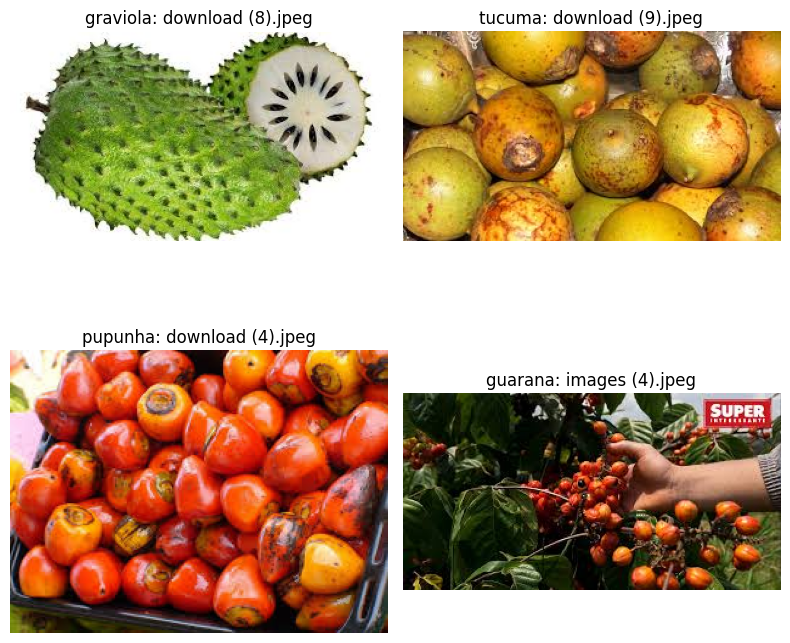

Total images found across all specified directories: 40


In [14]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# 1. Set the base directories for your dataset
train_dir = '/content/drive/MyDrive/AI - level 6_Sem 2/FruitinAmazon/FruitinAmazon/train'
test_dir = '/content/drive/MyDrive/AI - level 6_Sem 2/FruitinAmazon/FruitinAmazon/test'

directories_to_process = [
    (train_dir, "Train"),
    (test_dir, "Test")
]

all_selected_images = []
total_images_found = 0

for current_dataset_base_dir, dataset_type_label in directories_to_process:
    print(f"Processing {dataset_type_label} directory: {current_dataset_base_dir}")

    if not os.path.isdir(current_dataset_base_dir):
        print(f"Error: Directory not found at {current_dataset_base_dir}. Please ensure your Google Drive is mounted and the path is correct.")
        continue

    # Get class subdirectories (fruit names)
    class_names = [d for d in os.listdir(current_dataset_base_dir) if os.path.isdir(os.path.join(current_dataset_base_dir, d))]

    if not class_names:
        print(f"No class subdirectories found in {current_dataset_base_dir}.")
        # If no class subdirectories, check if images are directly in the base directory
        all_images_in_base_dir = [f for f in os.listdir(current_dataset_base_dir) if f.lower().endswith(('.jpeg', '.jpg', '.jpeg', '.gif', '.bmp'))]
        if all_images_in_base_dir:
            total_images_found += len(all_images_in_base_dir)
            num_images_to_display_per_set = min(2, len(all_images_in_base_dir)) # Display up to 2 if available
            random_image_names = random.sample(all_images_in_base_dir, num_images_to_display_per_set)
            for img_name in random_image_names:
                all_selected_images.append((os.path.join(current_dataset_base_dir, img_name), f"{dataset_type_label} (No Class)"))
            print(f"Found {len(all_images_in_base_dir)} images directly in {current_dataset_base_dir}. Selected {num_images_to_display_per_set} random images.")
        else:
            print(f"No images or class subdirectories found in {current_dataset_base_dir}.")

    else:
        print(f"Found classes: {class_names} in {current_dataset_base_dir}")

        # Select 1-2 random images from each class, up to a total of 2 images per dataset type (train/test)
        num_images_selected_for_this_set = 0
        random.shuffle(class_names) # Randomize class order to ensure diverse selection

        for class_name in class_names:
            if num_images_selected_for_this_set >= 2: # Limit to 2 images per train/test set
                break

            class_path = os.path.join(current_dataset_base_dir, class_name)
            images_in_class = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]

            if images_in_class:
                total_images_found += len(images_in_class)
                # Select 1 random image from this class
                random_image_name = random.choice(images_in_class)
                all_selected_images.append((os.path.join(class_path, random_image_name), class_name))
                num_images_selected_for_this_set += 1
                print(f"  - Selected 1 image from class '{class_name}'. Total selected for {dataset_type_label}: {num_images_selected_for_this_set}")
            else:
                print(f"  - No images found in class '{class_name}'.")

num_images_to_display = len(all_selected_images)

# 4. Display the images in a grid format using matplotlib.
if num_images_to_display == 0:
    print("No images to display from either train or test directories.")
else:
    # Set up a 2x2 grid for 4 images (e.g., 2 from train, 2 from test)
    num_rows = 2
    num_cols = 2

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 4, num_rows * 4))
    axes = axes.flatten() # Flatten the 2x2 array of axes for easy iteration

    for i, (image_path, class_name) in enumerate(all_selected_images):
        if i >= num_rows * num_cols: # Prevent exceeding subplot limits if more than 4 images are somehow selected
            break
        ax = axes[i]
        try:
            img = Image.open(image_path)
            ax.imshow(img)
            ax.set_title(class_name + ": " + os.path.basename(image_path))
            ax.axis('off')
        except Exception as e:
            print(f"Could not load image {image_path}: {e}")
            ax.axis('off') # Hide axis for failed image

    # Hide any unused subplots if num_images_to_display is less than num_rows * num_cols
    for i in range(num_images_to_display, num_rows * num_cols):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()

print(f"Total images found across all specified directories: {total_images_found}")

## Corrupted Image Detection and Removal

This script iterates through the training dataset, attempting to open and verify each image file. If an image is found to be corrupted (e.g., due to an `IOError` or `SyntaxError` during verification), it is removed from the directory, and a log message is printed. This step is crucial for maintaining data quality and preventing issues during model training.

In [15]:
import os
from PIL import Image

# Define the train directory based on the previous cell's context
train_dir = '/content/drive/MyDrive/AI - level 6_Sem 2/FruitinAmazon/FruitinAmazon/train'

corrupted_images = []

if not os.path.isdir(train_dir):
    print(f"Error: Training directory not found at {train_dir}.")
else:
    print(f"Checking for corrupted images in: {train_dir}")

    # Iterate through each class subdirectory
    for class_name in os.listdir(train_dir):
        class_path = os.path.join(train_dir, class_name)

        if os.path.isdir(class_path):
            print(f"  Checking class: {class_name}")
            for image_name in os.listdir(class_path):
                image_path = os.path.join(class_path, image_name)

                if os.path.isfile(image_path) and image_name.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                    try:
                        img = Image.open(image_path)
                        img.verify() # Verify that it is, in fact, an image
                    except (IOError, SyntaxError) as e:
                        print(f"Removed corrupted image: {image_path} (Error: {e})")
                        corrupted_images.append(image_path)
                        os.remove(image_path)

# Report results
if not corrupted_images:
    print("No corrupted images found.")
else:
    print(f"\nFound and removed {len(corrupted_images)} corrupted images:")
    for img_path in corrupted_images:
        print(f"- {img_path}")

Checking for corrupted images in: /content/drive/MyDrive/AI - level 6_Sem 2/FruitinAmazon/FruitinAmazon/train
  Checking class: acai
  Checking class: cupuacu
  Checking class: graviola
  Checking class: guarana
  Checking class: tucuma
  Checking class: pupunha
No corrupted images found.


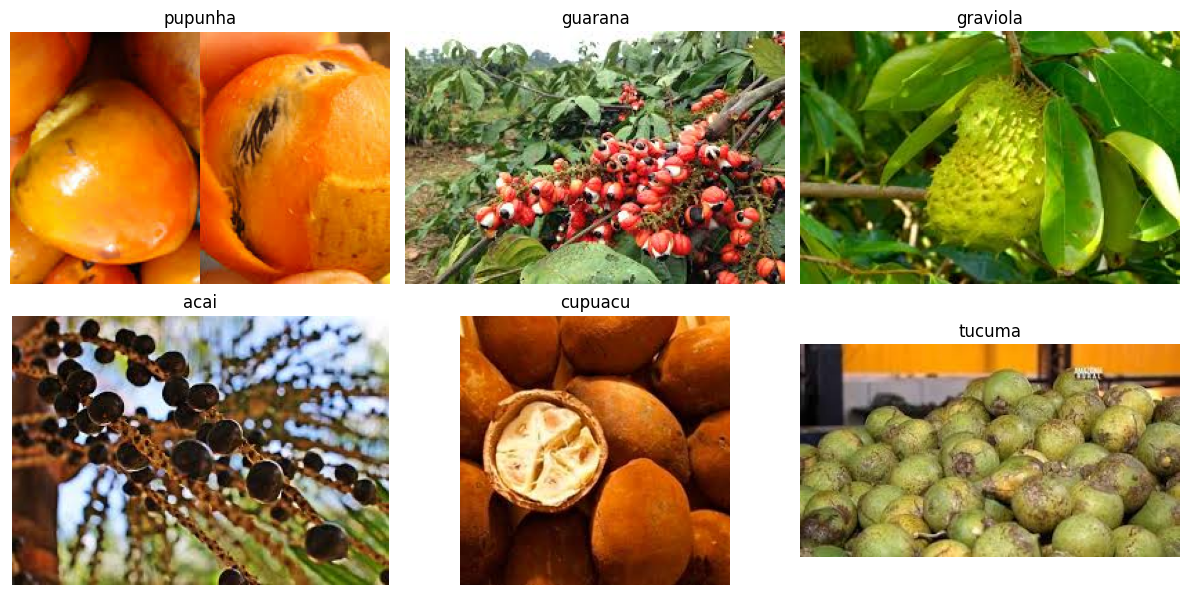

In [16]:
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


selected_images = [] # Store image paths
selected_labels = [] # Store corresponding class names
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if images: # Ensure the class folder is not empty
            selected_img = os.path.join(class_path, random.choice(images))
            selected_images.append(selected_img)
            selected_labels.append(class_name)



# Determine grid size
num_classes = len(selected_images)
cols = (num_classes + 1) // 2 # Determine columns
rows = 2 # Fixed rows for layout
fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < num_classes:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i])
        ax.axis("off")
    else:
        ax.axis("off") # Hide empty subplots
plt.tight_layout()
plt.show()

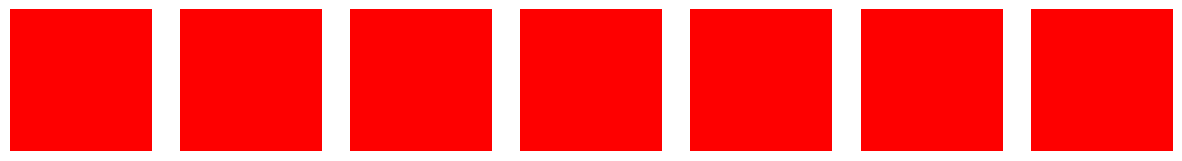

In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np

datagen = ImageDataGenerator(
    rotation_range=30,  # Rotate images by up to 30 degrees
    width_shift_range=0.2,  # Shift width by 20%
    height_shift_range=0.2,  # Shift height by 20%
    shear_range=0.2,  # Shear transformation
    zoom_range=0.2,  # Zoom in/out by 20%
    horizontal_flip=True,  # Flip images horizontally
    fill_mode='nearest'  # Fill in missing pixels
)

# Load an example image
# You might need to provide an actual image path here, e.g., from your dataset
# For demonstration, I'll assume 'sample.jpg' exists or replace with a known path.
# If 'sample.jpg' does not exist, this will raise a FileNotFoundError.
# As a placeholder, let's create a dummy image if not available.
try:
    img_path = 'sample.jpg'
    img = image.load_img(img_path, target_size=(128, 128))
except FileNotFoundError:
    print(f"Warning: '{img_path}' not found. Creating a dummy image for demonstration.")
    # Create a dummy white image if sample.jpg doesn't exist
    from PIL import Image
    dummy_img = Image.new('RGB', (128, 128), color = 'red')
    dummy_img.save('sample.jpg')
    img = image.load_img('sample.jpg', target_size=(128, 128))

x = image.img_to_array(img)  # Convert to NumPy array
x = np.expand_dims(x, axis=0)

# Generate augmented images
aug_iter = datagen.flow(x, batch_size=1)

# Visualize 7 augmented images
fig, ax = plt.subplots(1, 7, figsize=(15, 5))
for i in range(7):
    batch = next(aug_iter)
    ax[i].imshow(batch[0].astype('uint8'))
    ax[i].axis('off')
plt.show()

In [18]:
import tensorflow as tf

# Define image size and batch size
img_height = 128  # Example image height
img_width = 128   # Example image width
batch_size = 32
validation_split = 0.2  # 80% training, 20% validation

# The preprocessing layer for normalization (rescale) is now integrated into the model architecture.
# Therefore, we no longer define it here or apply it using .map() on the datasets.
# rescale = tf.keras.layers.Rescaling(1./255)

print(f"Creating training dataset from: {train_dir}")
# Create training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

# Normalization is now handled by the model itself, no need to apply here.
# train_ds = train_ds.map(lambda x, y: (rescale(x), y))

print(f"Creating validation dataset from: {train_dir}")
# Create validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False, # Typically no shuffle for validation
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# Normalization is now handled by the model itself, no need to apply here.
# val_ds = val_ds.map(lambda x, y: (rescale(x), y))

print(f"Creating test dataset from: {test_dir}")
# Create test dataset
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False, # Typically no shuffle for test set
    seed=123 # Use a seed for reproducibility if needed, but not strictly necessary for test set
)

# Normalization is now handled by the model itself, no need to apply here.
# test_ds = test_ds.map(lambda x, y: (rescale(x), y))

print("Datasets created without external preprocessing (now integrated into model).")
print(f"Number of training batches: {len(train_ds)}")
print(f"Number of validation batches: {len(val_ds)}")
print(f"Number of test batches: {len(test_ds)}")

Creating training dataset from: /content/drive/MyDrive/AI - level 6_Sem 2/FruitinAmazon/FruitinAmazon/train
Found 90 files belonging to 6 classes.
Using 72 files for training.
Creating validation dataset from: /content/drive/MyDrive/AI - level 6_Sem 2/FruitinAmazon/FruitinAmazon/train
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Creating test dataset from: /content/drive/MyDrive/AI - level 6_Sem 2/FruitinAmazon/FruitinAmazon/test
Found 30 files belonging to 6 classes.
Datasets created without external preprocessing (now integrated into model).
Number of training batches: 3
Number of validation batches: 1
Number of test batches: 1


In [19]:
# This line is no longer needed as data augmentation layers are now part of the Keras model itself.
# The model will apply augmentation automatically during training.
# augmented_train_ds = train_ds.map(lambda x, y: (data_augmentation(x), y))

In [20]:
import tensorflow as tf
from tensorflow.keras import layers

# These layers are now integrated directly into the model for on-the-fly augmentation.
# The data_augmentation function below is typically used when applying augmentation via dataset.map().
# If using a Keras Sequential model with augmentation layers directly, this function might not be used.
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
]

def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

## 2. Loading and Preprocessing Image Data for Keras

This section utilizes TensorFlow's `image_dataset_from_directory` function to efficiently load and preprocess images for a Keras-based image classification model. It automatically infers labels from subdirectory names, resizes images, and applies batching. Note that the `Rescaling` layer (for normalizing pixel values) and data augmentation layers are now integrated directly into the model architecture for consistent application during training and inference.

In [21]:
# This cell is a duplicate of the dataset creation and preprocessing logic found in cell -4yzWhewk9d.
# The primary dataset creation is handled there, with preprocessing (rescaling) now integrated into the model.
# Therefore, this duplicate cell is no longer needed.

Normalization(Rescaling):

In [22]:
# This cell previously defined the 'rescale' layer, but it is now integrated directly into the model.
# Therefore, this cell is no longer needed.

ImageandBatchSizeParameters:

In [23]:
# This cell previously defined image and batch size parameters, but they are already defined in cell -4yzWhewk9d and used globally.
# Therefore, this cell is no longer needed.

Task 3- Implement a CNN with

Convolutional Architecture:

In [24]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import BatchNormalization, Activation, Dropout # Added Activation and Dropout
import os # Import os module to get class names

# Ensure num_classes is defined for model creation
# This assumes train_dir is defined and contains class subdirectories
if 'num_classes' not in locals() or 'num_classes' not in globals():
    if 'train_dir' in locals() or 'train_dir' in globals():
        class_names = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
        num_classes = len(class_names)
        print(f"Dynamically determined num_classes: {num_classes}")
    else:
        raise ValueError("train_dir not defined. Cannot determine num_classes.")

# Define the CNN model based on the requested architecture
model = keras.Sequential([
    # Data augmentation applied using Lambda layer
    layers.Lambda(data_augmentation, input_shape=(img_height, img_width, 3)),

    # Rescaling layer to normalize pixel values
    layers.Rescaling(1./255),

    # First ConvolutionalBlock
    layers.Conv2D(32, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Second ConvolutionalBlock
    layers.Conv2D(64, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Third ConvolutionalBlock
    layers.Conv2D(128, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Fourth ConvolutionalBlock
    layers.Conv2D(256, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Flatten the output of the last Conv2D layer
    layers.Flatten(),

    # First FullyConnectedLayer
    layers.Dense(512, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # Second FullyConnectedLayer
    layers.Dense(256, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # Third FullyConnectedLayer
    layers.Dense(128, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # Fourth FullyConnectedLayer
    layers.Dense(64, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    # Output Layer with num_classes neurons
    layers.Dense(num_classes, activation='softmax') # num_classes determined from the dataset
])

print("Model architecture created successfully with data augmentation, rescaling, batch normalization, and dropout layers.")
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model architecture created successfully with data augmentation, rescaling, batch normalization, and dropout layers.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             

 Total params: 8,956,166 (34.17 MB)

 Trainable params: 8,953,286 (34.15 MB)

 Non-trainable params: 2,880 (11.25 KB)

## 4. Compile the Model

This section compiles the CNN model by defining the optimizer, loss function, and metrics. We'll use the Adam optimizer, SparseCategoricalCrossentropy as the loss function (suitable for integer labels), and accuracy as the evaluation metric.

In [25]:
# Compile the model
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False), # from_logits=False because output layer uses softmax
    metrics=['accuracy']
)

print("Model compiled successfully.")

Model compiled successfully.


## 5. Train the Model

This section trains the compiled CNN model using the `model.fit()` function. It sets the batch size to 16, the number of epochs to 250, and uses the validation dataset (`val_ds`) for monitoring performance during training. To optimize the training process, `ModelCheckpoint` is used to save the best model based on validation accuracy, and `EarlyStopping` is implemented to halt training if validation accuracy does not improve for a certain number of epochs, preventing overfitting.

Starting model training for 250 epochs...
Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1696 - loss: 2.1371
Epoch 1: val_accuracy improved from None to 0.00000, saving model to /tmp/checkpoint.weights.h5

Epoch 1: finished saving model to /tmp/checkpoint.weights.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.1806 - loss: 2.1326 - val_accuracy: 0.0000e+00 - val_loss: 1.7574
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2396 - loss: 2.2292
Epoch 2: val_accuracy improved from 0.00000 to 0.22222, saving model to /tmp/checkpoint.weights.h5

Epoch 2: finished saving model to /tmp/checkpoint.weights.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.2500 - loss: 2.1784 - val_accuracy: 0.2222 - val_loss: 1.7839
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1250 - loss: 2.3060
Epoch 3: val_accuracy did not improve from 0.22222
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.1250 - loss: 2.3050 - val_accuracy: 0.1111 - val_loss: 1.7732


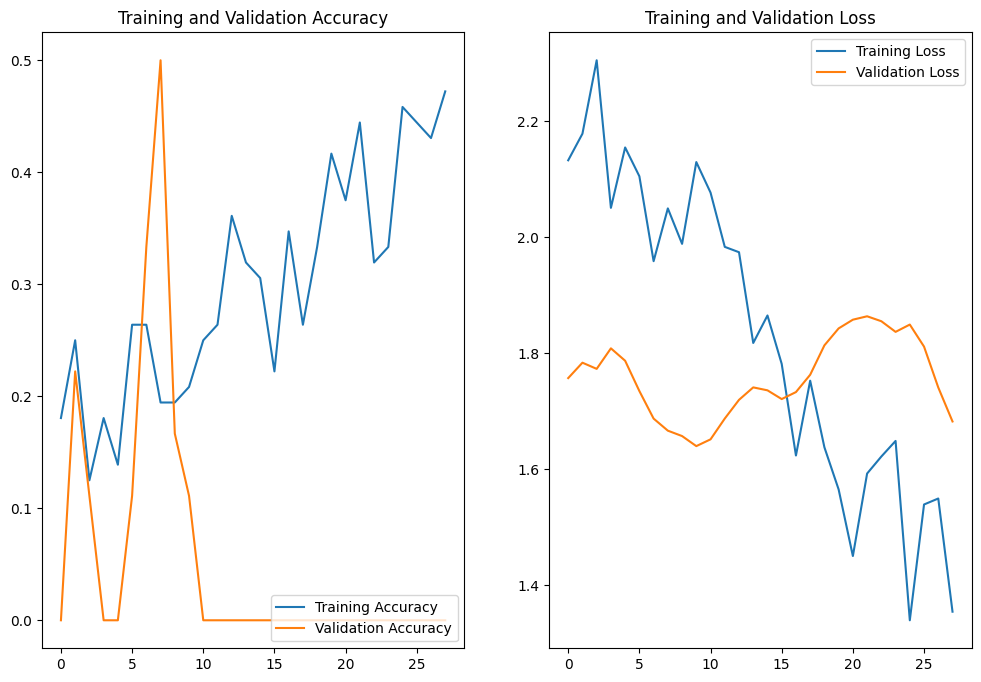

In [26]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt # Import for plotting training history

epochs = 250

# Define Callbacks
checkpoint_filepath = '/tmp/checkpoint.weights.h5' # Changed filepath to end with .weights.h5
model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=True,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

early_stopping_callback = EarlyStopping(
    monitor='val_accuracy',
    patience=20, # Number of epochs with no improvement after which training will be stopped.
    mode='max',
    restore_best_weights=True,
    verbose=1
)

print(f"Starting model training for {epochs} epochs...")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=[model_checkpoint_callback, early_stopping_callback]
)

print("Model training finished.")

# Visualize training history
# Get the training and validation accuracy and loss from the history object
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

## 8. Image Classification via Fine-tuning with VGG16

This section implements image classification using a pre-trained VGG16 model (transfer learning). The VGG16 model is loaded without its top classification layers, and its base layers are frozen to retain the learned features from ImageNet. Custom classification layers are then added on top, followed by compiling the new model.

In [34]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
import os

# Ensure img_height, img_width are defined.
if 'img_height' not in globals():
    img_height = 128  # Default value from cell -4yzWhewk9d
if 'img_width' not in globals():
    img_width = 128   # Default value from cell -4yzWhewk9d

# Ensure train_dir is defined
if 'train_dir' not in globals():
    train_dir = '/content/drive/MyDrive/AI - level 6_Sem 2/FruitinAmazon/FruitinAmazon/train'
    print(f"Recovered train_dir: {train_dir}")

# Ensure num_classes is defined.
if 'num_classes' not in globals():
    # Attempt to determine num_classes from train_dir if not defined
    if os.path.isdir(train_dir):
        class_names = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
        num_classes = len(class_names)
        print(f"Recovered num_classes: {num_classes}")
    else:
        # Fallback or error if train_dir is also not defined
        raise ValueError(f"Training directory not found at {train_dir}. Cannot determine num_classes.")

# 1. Load the VGG16 model pre-trained on ImageNet, without the top classification layer
#    The input_shape should match the img_height and img_width defined earlier.
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

print("VGG16 base model loaded successfully.")

VGG16 base model loaded successfully.


In [35]:
# 2. Freeze the layers of the base model
#    This prevents the pre-trained weights from being updated during initial training.
for layer in base_model.layers:
    layer.trainable = False

print("VGG16 base model layers frozen.")

VGG16 base model layers frozen.


In [36]:
# 3. Add custom layers on top of the pre-trained model
#    The number of output neurons in the final Dense layer should match num_classes.
x = base_model.output
x = GlobalAveragePooling2D()(x) # Reduces dimensions (height, width) to a single vector per image
x = Dense(1024, activation='relu')(x) # Fully connected layer with 1024 neurons
x = Dense(num_classes, activation='softmax')(x) # Output layer for 'num_classes' (with softmax for multi-class classification)

print(f"Custom layers added with {num_classes} output neurons.")

Custom layers added with 6 output neurons.


In [37]:
# 4. Create the final model by combining the base model and custom layers
model_transfer = Model(inputs=base_model.input, outputs=x)

print("Final transfer learning model created.")
model_transfer.summary()

Final transfer learning model created.


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │         6,150 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,246,150 (58.16 MB)

 Trainable params: 531,462 (2.03 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [38]:
from tensorflow.keras.optimizers import Adam

# 5. Compile the transfer learning model
model_transfer.compile(
    optimizer=Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False), # Use SparseCategoricalCrossentropy for integer labels
    metrics=['accuracy']
)

print("Transfer learning model compiled successfully.")

Transfer learning model compiled successfully.


Starting VGG16 transfer learning model training for 50 epochs...
Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.0943 - loss: 9.4935
Epoch 1: val_accuracy improved from None to 0.22222, saving model to /tmp/vgg16_transfer_checkpoint.weights.h5

Epoch 1: finished saving model to /tmp/vgg16_transfer_checkpoint.weights.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 23s 6s/step - accuracy: 0.1111 - loss: 10.1137 - val_accuracy: 0.2222 - val_loss: 12.7684
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6140 - loss: 3.5304
Epoch 2: val_accuracy improved from 0.22222 to 0.61111, saving model to /tmp/vgg16_transfer_checkpoint.weights.h5

Epoch 2: finished saving model to /tmp/vgg16_transfer_checkpoint.weights.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 6s/step - accuracy: 0.6389 - loss: 3.0330 - val_accuracy: 0.6111 - val_loss: 2.6120
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8605 - loss: 0.9213
Epoch 3: val_accuracy improved from 0.61111 to 0.83333, saving model to /tmp/vgg16_tr

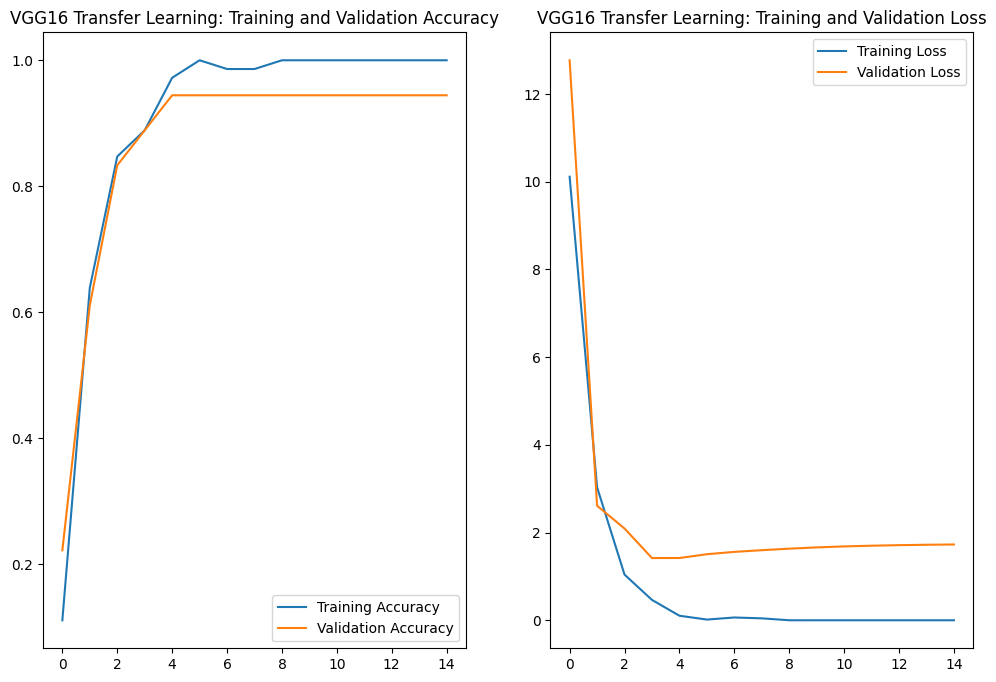

In [39]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt # Import for plotting training history

epochs = 50 # Start with a reasonable number of epochs, can be adjusted

# Define Callbacks
checkpoint_filepath_transfer = '/tmp/vgg16_transfer_checkpoint.weights.h5'
model_checkpoint_callback_transfer = ModelCheckpoint(
    filepath=checkpoint_filepath_transfer,
    save_weights_only=True,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

early_stopping_callback_transfer = EarlyStopping(
    monitor='val_accuracy',
    patience=10, # Reduced patience for faster iteration, can be adjusted
    mode='max',
    restore_best_weights=True,
    verbose=1
)

print(f"Starting VGG16 transfer learning model training for {epochs} epochs...")

history_transfer = model_transfer.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=[model_checkpoint_callback_transfer, early_stopping_callback_transfer]
)

print("VGG16 transfer learning model training finished.")

# Visualize training history
acc_transfer = history_transfer.history['accuracy']
val_acc_transfer = history_transfer.history['val_accuracy']
loss_transfer = history_transfer.history['loss']
val_loss_transfer = history_transfer.history['val_loss']

epochs_range_transfer = range(len(acc_transfer))

plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range_transfer, acc_transfer, label='Training Accuracy')
plt.plot(epochs_range_transfer, val_acc_transfer, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('VGG16 Transfer Learning: Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range_transfer, loss_transfer, label='Training Loss')
plt.plot(epochs_range_transfer, val_loss_transfer, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('VGG16 Transfer Learning: Training and Validation Loss')
plt.show()

## 6. Save the Trained Model

This section saves the entire trained Keras model to an .h5 file. This file will include the model's architecture, learned weights, and the configuration (optimizer, loss function, etc.) allowing it to be reloaded and used later without needing to rebuild the model from scratch.

## 6. Evaluate the Model

After training, this section evaluates the model's performance on the unseen test dataset using `model.evaluate()`. This provides final metrics like test loss and test accuracy to assess how well the model generalizes to new data.

In [32]:
import os

# Define the path to save the entire model
saved_model_path = '/tmp/fruit_classifier_model.h5'

# Save the entire model (architecture, weights, and optimizer state)
model.save(saved_model_path)

print(f"Model saved successfully to: {saved_model_path}")

# Optionally, load the best weights from the checkpoint into the model before saving
# This ensures the saved model reflects the best performance during training
# model.load_weights(checkpoint_filepath)
# model.save(saved_model_path.replace('.h5', '_best_weights.h5'))
# print(f"Model with best weights saved successfully to: {saved_model_path.replace('.h5', '_best_weights.h5')}")

Model saved successfully to: /tmp/fruit_classifier_model.h5


## 7. Load Model and Make Predictions

This section demonstrates how to load the previously saved model and use it to predict the class of a new, unseen image. A random image from the test dataset will be selected, preprocessed, and then passed to the model for prediction. The actual and predicted class labels will be displayed.

In [40]:
print("Evaluating VGG16 transfer learning model on the test set...")
# Ensure model_transfer is available from previous cells
if 'model_transfer' not in globals():
    raise NameError("model_transfer is not defined. Please ensure the VGG16 model setup and training cells have been executed.")

test_loss_transfer, test_accuracy_transfer = model_transfer.evaluate(test_ds)

print(f"Test Loss (VGG16 Transfer Learning Model): {test_loss_transfer:.4f}")
print(f"Test Accuracy (VGG16 Transfer Learning Model): {test_accuracy_transfer:.4f}")

Evaluating VGG16 transfer learning model on the test set...
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - accuracy: 0.5000 - loss: 5.5303
Test Loss (VGG16 Transfer Learning Model): 5.5303
Test Accuracy (VGG16 Transfer Learning Model): 0.5000


## 7. Classification Report

This section uses the trained model to make predictions on the entire test dataset and then generates a detailed classification report. The report will include metrics such as precision, recall, f1-score, and support for each class, providing a comprehensive evaluation of the model's performance beyond just overall accuracy.

In [41]:
from sklearn.metrics import classification_report
import numpy as np

# Get true labels from the test dataset
true_labels = []
for images, labels in test_ds:
    true_labels.extend(labels.numpy())

# Make predictions on the test dataset using model_transfer
predictions_probabilities = model_transfer.predict(test_ds)
predicted_labels = np.argmax(predictions_probabilities, axis=1)

# Get class names from the test_ds or as defined earlier
# Ensure class_names is sorted to match the order of labels from image_dataset_from_directory
class_names = sorted([d for d in os.listdir(test_dir) if os.path.isdir(os.path.join(test_dir, d))])

# Generate and print the classification report
print("\nClassification Report (VGG16 Transfer Learning Model):")
print(classification_report(true_labels, predicted_labels, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step

Classification Report (VGG16 Transfer Learning Model):
              precision    recall  f1-score   support

        acai       0.33      0.60      0.43         5
     cupuacu       0.67      0.80      0.73         5
    graviola       1.00      0.60      0.75         5
     guarana       1.00      0.20      0.33         5
     pupunha       0.33      0.20      0.25         5
      tucuma       0.38      0.60      0.46         5

    accuracy                           0.50        30
   macro avg       0.62      0.50      0.49        30
weighted avg       0.62      0.50      0.49        30



In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

# Ensure required variables from previous cells are available
# model_transfer, class_names, img_height, img_width

if 'model_transfer' not in globals():
    print("Error: 'model_transfer' not found. Please ensure the VGG16 model setup and training cells have been executed.")
elif 'class_names' not in globals():
    # Attempt to determine class_names if not in globals
    if 'train_dir' in globals() and os.path.isdir(train_dir):
        class_names = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
        print(f"Recovered class_names: {class_names}")
    else:
        print("Error: 'class_names' or 'train_dir' not found. Cannot proceed with prediction.")
elif 'img_height' not in globals() or 'img_width' not in globals():
    print("Error: 'img_height' or 'img_width' not found. Please ensure the preprocessing setup cell (Cell 2) has been executed.")
else:
    # Define the preprocessing steps consistent with model training
    # The Rescaling layer (1./255) is already part of the model_transfer itself for VGG16
    # No external rescale operation is needed here since the model handles it.

    # --- User Input for Image Path from Google Drive ---
    image_path_from_drive = input("Please enter the path to the image in your Google Drive (e.g., /content/drive/MyDrive/my_image.jpg):")

    if not os.path.exists(image_path_from_drive):
        print(f"Error: File not found at '{image_path_from_drive}'. Please check the path and ensure Google Drive is mounted.")
    else:
        try:
            # --- Preprocess the image ---
            img = Image.open(image_path_from_drive).convert('RGB') # Ensure 3 channels
            img_resized = img.resize((img_height, img_width)) # Resize to model's expected input
            img_array = np.asarray(img_resized) # Convert to numpy array
            img_array = np.expand_dims(img_array, axis=0) # Add batch dimension (1, height, width, channels)

            # --- Make prediction ---
            # The model_transfer already includes the Rescaling layer (1./255)
            predictions = model_transfer.predict(img_array)
            probabilities = predictions[0] # Get probabilities for the single image
            predicted_class_index = np.argmax(probabilities)
            max_probability = np.max(probabilities)

            # --- Define a confidence threshold (adjust as needed) ---
            confidence_threshold = 0.75 # If max probability is below this, consider it unknown

            # --- Display results ---
            plt.figure(figsize=(6, 6))
            plt.imshow(img) # Display the original, unnormalized image
            plt.axis('off')

            if max_probability >= confidence_threshold:
                predicted_class_name = class_names[predicted_class_index]
                title_text = f"Predicted: {predicted_class_name} ({max_probability*100:.2f}% confidence)"
                print(f"Predicted Class: {predicted_class_name} with {max_probability*100:.2f}% confidence.")
            else:
                title_text = f"Prediction: Does not clearly belong to a known fruit (Max confidence: {max_probability*100:.2f}%)"
                print(f"The image does not clearly belong to any known fruit category based on a {confidence_threshold*100:.0f}% confidence threshold. Max confidence: {max_probability*100:.2f}%")

            plt.title(title_text)
            plt.show()

            print("\nAll class probabilities:")
            for i, prob in enumerate(probabilities):
                print(f"- {class_names[i]}: {prob*100:.2f}%")

        except Exception as e:
            print(f"An error occurred during image processing or prediction: {e}")
            print("Please ensure the image file is valid and accessible.")